In [1]:
from util import *


# RQ1

In [ ]:

RQ1consensus_file_05 = r"dataset\seed_MSA\RF00005.stockholm.txt"
RQ1cacofold_file_05 = r"RQ1\results\05\RF00005_tRNA.cacofold.sto"

RQ1consensus_file_23 = r"dataset\seed_MSA\RF00023.stockholm.txt"
RQ1cacofold_file_23 = r"RQ1\results\23\RF00023_tmRNA.cacofold.sto"

RQ1consensus_file_162 = r"dataset\seed_MSA\RF00162.stockholm.txt"
RQ1cacofold_file_162 = r"RQ1\results\162\RF00162_SAM.cacofold.sto"

RQ1consensus_05 = extract_consensus_structure(RQ1consensus_file_05)
RQ1cacofold_05 = extract_cacofold_structure(RQ1cacofold_file_05)
RQ1results_05 = compare_structures(RQ1consensus_05, RQ1cacofold_05)

RQ1consensus_23 = extract_consensus_structure(RQ1consensus_file_23)
RQ1cacofold_23 = extract_cacofold_structure(RQ1cacofold_file_23)
RQ1results_23 = compare_structures(RQ1consensus_23, RQ1cacofold_23)

RQ1consensus_162 = extract_consensus_structure(RQ1consensus_file_162)
RQ1cacofold_162 = extract_cacofold_structure(RQ1cacofold_file_162)
RQ1results_162 = compare_structures(RQ1consensus_162, RQ1cacofold_162)

print("Results 05:", RQ1results_05)
print("Results 23:", RQ1results_23)
print("Results 162:", RQ1results_162)



# RQ2

In [ ]:
RQ2consensus_file_162 = r"dataset\seed_MSA\RF00162.stockholm.txt"

fractions = [75, 50, 25, 10, 5, 3, 1]
seeds = [1, 2, 3, 4, 5]

RQ2consensus_162 = extract_consensus_structure(RQ2consensus_file_162)

RQ2results = {}

for seed in seeds:
    RQ2results[seed] = {}

    for frac in fractions:
        path = fr"RQ2\{frac}\{seed}\RF00162_SAM.cacofold.sto"

        structure = extract_cacofold_structure(path)
        comparison = compare_structures(RQ2consensus_162, structure)

        RQ2results[seed][frac] = comparison

        print(f"Seed {seed} | {frac}%: {comparison}")

RQ2rows = []

for seed in RQ2results:
    for frac in RQ2results[seed]:
        r = RQ2results[seed][frac]

        RQ2rows.append({
            "seed": seed,
            "fraction": frac,
            "precision": r["precision"],
            "recall": r["recall"],
            "TP": r["TP"],
            "FP": r["FP (extra CaCoFold)"],
            "FN": r["FN"],
            "helices_pred": r["k_helices"]["num_helices"],
            "helices_cons": r["c_helices"]["num_helices"],
        })

import pandas as pd
RQ2df = pd.DataFrame(RQ2rows)

RQ2df["f1"] = (
    2 * RQ2df["precision"] * RQ2df["recall"] /
    (RQ2df["precision"] + RQ2df["recall"])
)

RQ2summary = RQ2df.groupby("fraction").agg(["mean", "std"])
RQ2summary

Seed 1 | 75%: {'TP': 17, 'FP (extra CaCoFold)': 4, 'FN': 1, 'precision': 0.8095238095238095, 'recall': 0.9444444444444444, 'c_knots': 0, 'k_knots': 0, 'c_helices': {'num_helices': 10, 'avg_length': 1.8, 'max_length': 4}, 'k_helices': {'num_helices': 11, 'avg_length': 1.9090909090909092, 'max_length': 3}}
Seed 1 | 50%: {'TP': 17, 'FP (extra CaCoFold)': 2, 'FN': 1, 'precision': 0.8947368421052632, 'recall': 0.9444444444444444, 'c_knots': 0, 'k_knots': 0, 'c_helices': {'num_helices': 10, 'avg_length': 1.8, 'max_length': 4}, 'k_helices': {'num_helices': 11, 'avg_length': 1.7272727272727273, 'max_length': 3}}
Seed 1 | 25%: {'TP': 17, 'FP (extra CaCoFold)': 2, 'FN': 1, 'precision': 0.8947368421052632, 'recall': 0.9444444444444444, 'c_knots': 0, 'k_knots': 0, 'c_helices': {'num_helices': 10, 'avg_length': 1.8, 'max_length': 4}, 'k_helices': {'num_helices': 11, 'avg_length': 1.7272727272727273, 'max_length': 3}}
Seed 1 | 10%: {'TP': 17, 'FP (extra CaCoFold)': 2, 'FN': 1, 'precision': 0.8947368

seed           precision              recall              TP  \
         mean       std      mean       std      mean       std  mean   
fraction                                                                
1         3.0  1.581139  0.604191  0.190346  0.777778  0.111111  14.0   
3         3.0  1.581139  0.768678  0.109391  0.844444  0.194047  15.2   
5         3.0  1.581139  0.824545  0.036164  0.933333  0.024845  16.8   
10        3.0  1.581139  0.904678  0.022230  0.944444  0.000000  17.0   
25        3.0  1.581139  0.885789  0.020007  0.944444  0.000000  17.0   
50        3.0  1.581139  0.859799  0.035920  0.944444  0.000000  17.0   
75        3.0  1.581139  0.802165  0.016456  0.944444  0.000000  17.0   

                      FP             FN           helices_pred            \
               std  mean       std mean       std         mean       std   
fraction                                                                   
1         2.000000  11.2  6.760178  4.0  2.000000         10.0  3.082207   
3         3.492850   4.4  1.673320  2.8  3.492850         10.2  1.303840   
5         0.447214   3.6  0.894427  1.2  0.447214         11.0  0.707107   
10        0.000000   1.8  0.447214  1.0  0.000000         10.8  0.447214   
25        0.000000   2.2  0.447214  1.0  0.000000         11.0  0.000000   
50        0.000000   2.8  0.836660  1.0  0.000000         11.0  0.000000   
75        0.000000   4.2  0.447214  1.0  0.000000         11.2  0.447214   

         helices_cons             f1            
                 mean  std      mean       std  
fraction                                        
1                10.0  0.0  0.656788  0.074016  
3                10.0  0.0  0.801508  0.147231  
5                10.0  0.0  0.875263  0.026811  
10               10.0  0.0  0.924024  0.011415  
25               10.0  0.0  0.914083  0.010815  
50               10.0  0.0  0.899821  0.019790  
75               10.0  0.0  0.867436  0.009747

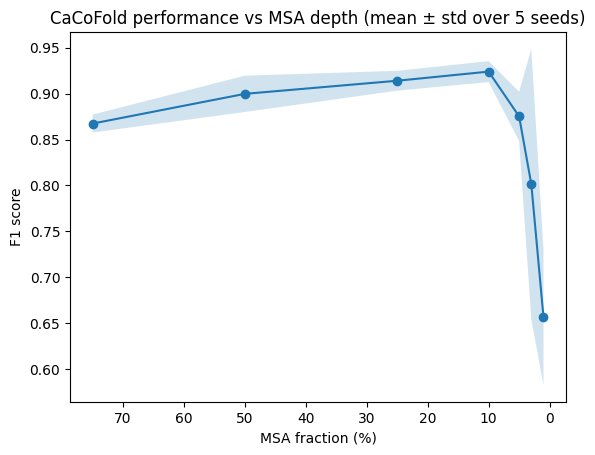

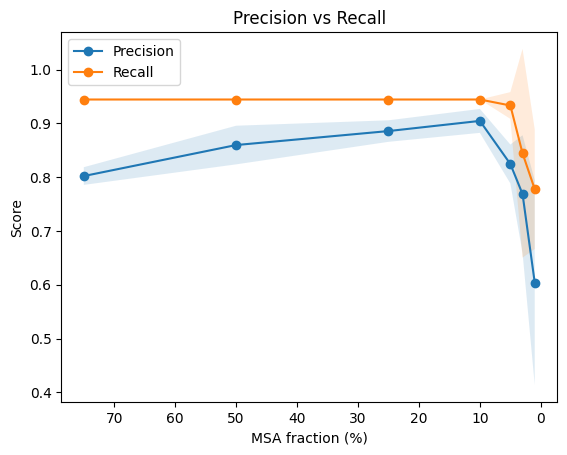

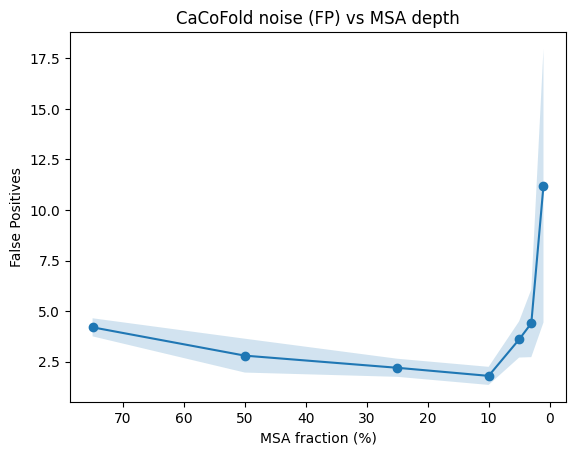

In [29]:
import matplotlib.pyplot as plt

fractions = summary.index.values

plt.figure()

plt.plot(fractions, summary["f1"]["mean"], marker="o")
plt.fill_between(
    fractions,
    summary["f1"]["mean"] - summary["f1"]["std"],
    summary["f1"]["mean"] + summary["f1"]["std"],
    alpha=0.2
)

plt.xlabel("MSA fraction (%)")
plt.ylabel("F1 score")
plt.title("CaCoFold performance vs MSA depth (mean ± std over 5 seeds)")
plt.gca().invert_xaxis()
plt.show()

plt.figure()

plt.plot(fractions, summary["precision"]["mean"], marker="o", label="Precision")
plt.plot(fractions, summary["recall"]["mean"], marker="o", label="Recall")

plt.fill_between(fractions,
                 summary["precision"]["mean"] - summary["precision"]["std"],
                 summary["precision"]["mean"] + summary["precision"]["std"],
                 alpha=0.15)

plt.fill_between(fractions,
                 summary["recall"]["mean"] - summary["recall"]["std"],
                 summary["recall"]["mean"] + summary["recall"]["std"],
                 alpha=0.15)

plt.xlabel("MSA fraction (%)")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.gca().invert_xaxis()
plt.show()

plt.figure()

plt.plot(fractions, summary["FP"]["mean"], marker="o")

plt.fill_between(
    fractions,
    summary["FP"]["mean"] - summary["FP"]["std"],
    summary["FP"]["mean"] + summary["FP"]["std"],
    alpha=0.2
)

plt.xlabel("MSA fraction (%)")
plt.ylabel("False Positives")
plt.title("CaCoFold noise (FP) vs MSA depth")
plt.gca().invert_xaxis()
plt.show()



# RQ3

In [5]:
from pathlib import Path

noise_levels = [1, 3, 5, 10, 25, 50, 75]
seeds = [1, 2, 3, 4, 5]

for noise in noise_levels:
    for seed in seeds:
        Path(f"RQ3_2/{noise}/{seed}").mkdir(parents=True, exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
input_file = r"dataset\seed_MSA\RF00162.stockholm.txt"

noise_levels = [1, 3, 5, 10, 25, 50, 75]
seeds = [1, 2, 3, 4, 5]

for noise in noise_levels:
    for seed in seeds:
        perturb_stockholm_local(input_file, noise, seed)

Created RQ3\1\1\RF00162_1_1.sto (4/457 sequences perturbed)
Created RQ3\1\2\RF00162_1_2.sto (4/457 sequences perturbed)
Created RQ3\1\3\RF00162_1_3.sto (4/457 sequences perturbed)
Created RQ3\1\4\RF00162_1_4.sto (4/457 sequences perturbed)
Created RQ3\1\5\RF00162_1_5.sto (4/457 sequences perturbed)
Created RQ3\3\1\RF00162_3_1.sto (13/457 sequences perturbed)
Created RQ3\3\2\RF00162_3_2.sto (13/457 sequences perturbed)
Created RQ3\3\3\RF00162_3_3.sto (13/457 sequences perturbed)


Created RQ3\3\4\RF00162_3_4.sto (13/457 sequences perturbed)
Created RQ3\3\5\RF00162_3_5.sto (13/457 sequences perturbed)
Created RQ3\5\1\RF00162_5_1.sto (22/457 sequences perturbed)
Created RQ3\5\2\RF00162_5_2.sto (22/457 sequences perturbed)
Created RQ3\5\3\RF00162_5_3.sto (22/457 sequences perturbed)
Created RQ3\5\4\RF00162_5_4.sto (22/457 sequences perturbed)
Created RQ3\5\5\RF00162_5_5.sto (22/457 sequences perturbed)
Created RQ3\10\1\RF00162_10_1.sto (45/457 sequences perturbed)
Created RQ3\10\2\RF00162_10_2.sto (45/457 sequences perturbed)
Created RQ3\10\3\RF00162_10_3.sto (45/457 sequences perturbed)
Created RQ3\10\4\RF00162_10_4.sto (45/457 sequences perturbed)
Created RQ3\10\5\RF00162_10_5.sto (45/457 sequences perturbed)
Created RQ3\25\1\RF00162_25_1.sto (114/457 sequences perturbed)
Created RQ3\25\2\RF00162_25_2.sto (114/457 sequences perturbed)
Created RQ3\25\3\RF00162_25_3.sto (114/457 sequences perturbed)
Created RQ3\25\4\RF00162_25_4.sto (114/457 sequences perturbed)
Cr

In [6]:
input_file = r"dataset\seed_MSA\RF00162.stockholm.txt"

noise_levels = [1, 3, 5, 10, 25, 50, 75]
seeds = [1, 2, 3, 4, 5]

for noise in noise_levels:
    for seed in seeds:
        perturb_stockholm_block(input_file, noise, seed)

Created RQ3_2\1\1\RF00162_1_1.sto (4/457 sequences, block misalignment)
Created RQ3_2\1\2\RF00162_1_2.sto (4/457 sequences, block misalignment)
Created RQ3_2\1\3\RF00162_1_3.sto (4/457 sequences, block misalignment)
Created RQ3_2\1\4\RF00162_1_4.sto (4/457 sequences, block misalignment)
Created RQ3_2\1\5\RF00162_1_5.sto (4/457 sequences, block misalignment)
Created RQ3_2\3\1\RF00162_3_1.sto (13/457 sequences, block misalignment)
Created RQ3_2\3\2\RF00162_3_2.sto (13/457 sequences, block misalignment)
Created RQ3_2\3\3\RF00162_3_3.sto (13/457 sequences, block misalignment)
Created RQ3_2\3\4\RF00162_3_4.sto (13/457 sequences, block misalignment)
Created RQ3_2\3\5\RF00162_3_5.sto (13/457 sequences, block misalignment)
Created RQ3_2\5\1\RF00162_5_1.sto (22/457 sequences, block misalignment)
Created RQ3_2\5\2\RF00162_5_2.sto (22/457 sequences, block misalignment)
Created RQ3_2\5\3\RF00162_5_3.sto (22/457 sequences, block misalignment)
Created RQ3_2\5\4\RF00162_5_4.sto (22/457 sequences, blo

In [10]:
RQ3consensus_file_162 = r"dataset\seed_MSA\RF00162.stockholm.txt"

fractions = [75, 50, 25, 10, 5, 3, 1]
seeds = [1, 2, 3, 4, 5]

RQ3consensus_162 = extract_consensus_structure(RQ3consensus_file_162)

RQ3results = {}

for seed in seeds:
    RQ3results[seed] = {}

    for frac in fractions:
        path = fr"RQ3\{frac}\{seed}\RF00162_SAM.cacofold.sto"

        structure = extract_cacofold_structure(path)
        comparison = compare_structures(RQ3consensus_162, structure)

        RQ3results[seed][frac] = comparison

        print(f"Seed {seed} | {frac}%: {comparison}")

RQ3rows = []

for seed in RQ3results:
    for frac in RQ3results[seed]:
        r = RQ3results[seed][frac]

        RQ3rows.append({
            "seed": seed,
            "fraction": frac,
            "precision": r["precision"],
            "recall": r["recall"],
            "TP": r["TP"],
            "FP": r["FP (extra CaCoFold)"],
            "FN": r["FN"],
            "helices_pred": r["k_helices"]["num_helices"],
            "helices_cons": r["c_helices"]["num_helices"],
        })

import pandas as pd
RQ3df = pd.DataFrame(RQ3rows)

RQ3df["f1"] = (
    2 * RQ3df["precision"] * RQ3df["recall"] /
    (RQ3df["precision"] + RQ3df["recall"])
)

RQ3summary = RQ3df.groupby("fraction").agg(["mean", "std"])
RQ3summary

Seed 1 | 75%: {'TP': 17, 'FP (extra CaCoFold)': 4, 'FN': 1, 'precision': 0.8095238095238095, 'recall': 0.9444444444444444, 'c_knots': 0, 'k_knots': 0, 'c_helices': {'num_helices': 10, 'avg_length': 1.8, 'max_length': 4}, 'k_helices': {'num_helices': 11, 'avg_length': 1.9090909090909092, 'max_length': 3}}
Seed 1 | 50%: {'TP': 17, 'FP (extra CaCoFold)': 4, 'FN': 1, 'precision': 0.8095238095238095, 'recall': 0.9444444444444444, 'c_knots': 0, 'k_knots': 0, 'c_helices': {'num_helices': 10, 'avg_length': 1.8, 'max_length': 4}, 'k_helices': {'num_helices': 11, 'avg_length': 1.9090909090909092, 'max_length': 3}}
Seed 1 | 25%: {'TP': 17, 'FP (extra CaCoFold)': 5, 'FN': 1, 'precision': 0.7727272727272727, 'recall': 0.9444444444444444, 'c_knots': 0, 'k_knots': 0, 'c_helices': {'num_helices': 10, 'avg_length': 1.8, 'max_length': 4}, 'k_helices': {'num_helices': 12, 'avg_length': 1.8333333333333333, 'max_length': 3}}
Seed 1 | 10%: {'TP': 17, 'FP (extra CaCoFold)': 4, 'FN': 1, 'precision': 0.8095238

seed           precision              recall         TP        FP  \
         mean       std      mean       std      mean  std  mean  std mean   
fraction                                                                     
1         3.0  1.581139  0.802165  0.016456  0.944444  0.0  17.0  0.0  4.2   
3         3.0  1.581139  0.794805  0.020154  0.944444  0.0  17.0  0.0  4.4   
5         3.0  1.581139  0.787446  0.020154  0.944444  0.0  17.0  0.0  4.6   
10        3.0  1.581139  0.787446  0.020154  0.944444  0.0  17.0  0.0  4.6   
25        3.0  1.581139  0.787446  0.020154  0.944444  0.0  17.0  0.0  4.6   
50        3.0  1.581139  0.794805  0.020154  0.944444  0.0  17.0  0.0  4.4   
75        3.0  1.581139  0.802165  0.016456  0.944444  0.0  17.0  0.0  4.2   

                     FN      helices_pred           helices_cons       \
               std mean  std         mean       std         mean  std   
fraction                                                                
1         0.447214  1.0  0.0         11.2  0.447214         10.0  0.0   
3         0.547723  1.0  0.0         11.4  0.547723         10.0  0.0   
5         0.547723  1.0  0.0         11.6  0.547723         10.0  0.0   
10        0.547723  1.0  0.0         11.6  0.547723         10.0  0.0   
25        0.547723  1.0  0.0         11.6  0.547723         10.0  0.0   
50        0.547723  1.0  0.0         11.4  0.547723         10.0  0.0   
75        0.447214  1.0  0.0         11.2  0.447214         10.0  0.0   

                f1            
              mean       std  
fraction                      
1         0.867436  0.009747  
3         0.863077  0.011938  
5         0.858718  0.011938  
10        0.858718  0.011938  
25        0.858718  0.011938  
50        0.863077  0.011938  
75        0.867436  0.009747